# Commissioning

*The bench day end to end: the machine measured step by step, its constants identified, a tune searched against exactly that machine, the record written, and the drive verifying itself under it.*

**Abstract.** The drive runs on constants held in the calibration record - the motor, the loop and observer gains, the injection, the dead-time table - and an uncommissioned board holds placeholders there. This notebook runs the bench-day procedure on the stand-in, and on a board with the knob flipped: the twelve steps of `Commissioning` one section at a time, each number read back where it is made; the four constants into a `Parameters` that says it was measured; a search of the firmware's own control law against plants drawn around exactly that machine; the winning tune written to the record, saved, and the drive verified under it. What it measures: a phase noise floor of 0.16 A rms at 9.5 ENOB and a sample point at tick 2360 of 2376; R 0.051 ohm, Ld 19.5 uH, Lq 29.4 uH and lambda 0.00546 V.s, the stand-in's truth recovered within 3 % except the flux at 9 %; a dead-time voltage of 0.50 V with a 0.30 A knee; an injection budget of 20 dB against a 10 dB threshold; and a searched tune whose innovation proxy is 1.7 degrees against the closed form's 11.2. What a reader takes to the bench: every number is the board's and every verdict the host's, a step that saw no current says so and the record's value stands in, and an offset that looks like a fault is reported rather than zeroed.

## 1 Setup

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

In [2]:
from coaxial import Coaxial63100

device = Coaxial63100(port=PORT, device=SIMULATED).open()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 2 The converters: the floor, the sample point, the offsets

`Commissioning` takes the rig and `arm` - what `gates.on()` is called with when a step needs the stage; without it the switching steps refuse. `run()` is the twelve steps under one `finally` that puts the stage down; here they go one section at a time, so each number is read back where it is made. `gate_supply()` comes first: under 7.3 V the 2EDL8034 is in UVLO and nothing switches whatever TIM1 does, which on the unmodified bench board is what AFE_ON high does to it. Then the noise floor per channel with the gates off, and on the zero vector with the stage armed - the difference is switch pickup - and the interrupt's own cost, read where the board can measure it.

In [3]:
from coaxial.control.commission import Commissioning

c = Commissioning(device, arm=dict(bypass_sto=True, ignore_interlock=True),
                  rated_rpm=3000.0)
print('gate supply', c.gate_supply())
afe = c.afe_noise()
for name, off in afe['gates_off'].items():
    on = afe['zero_vector'][name]
    print('%-8s %5.1f codes rms gates off, %5.1f on the zero vector, ENOB %.2f%s'
          % (name, off['sd'], on['sd'], off['enob'],
             ', %.4f A' % on['sd_amps'] if 'sd_amps' in on else ''))
print('sigma_i %.4f A over the three phases, ENOB %.1f; pickup %s A'
      % (afe['sigma_i'], afe['enob'],
         [round(v, 4) for v in afe['pickup_amps'].values()]))
lat = afe['latency']
print('ISR entry %.1f us after the trigger, cost %.1f us (%d cycles); '
      'to effect %d periods = %.0f us'
      % (lat['isr_entry_us'], lat['isr_cost_us'], lat['isr_cost_cycles'],
         lat['to_effect_periods'], lat['to_effect_us']))

gate supply {'volts': 11.055, 'powered': True}


Phase U   25.8 codes rms gates off,  25.8 on the zero vector, ENOB 9.52, 0.1635 A
Phase V   23.8 codes rms gates off,  23.8 on the zero vector, ENOB 9.63, 0.1509 A
Phase W   26.8 codes rms gates off,  26.8 on the zero vector, ENOB 9.46, 0.1699 A
DC bus     8.0 codes rms gates off,   8.0 on the zero vector, ENOB 11.21
sigma_i 0.1616 A over the three phases, ENOB 9.5; pickup [0.0, 0.0, 0.0] A
ISR entry 4.1 us after the trigger, cost 3.4 us (1620 cycles); to effect 2 periods = 40 us


`sample_point_scan` moves CCR5 across the period on the zero vector and keeps the tick with the least phase variance - after the ringing, before the next edge. It needs the stage switching: with nothing on the gates the scan is a walk through noise, and on this bench it once picked 990 of 2376, mid-period, where the pickup is worst. The tick it keeps is written to the record as `drv_trigger_ticks`.

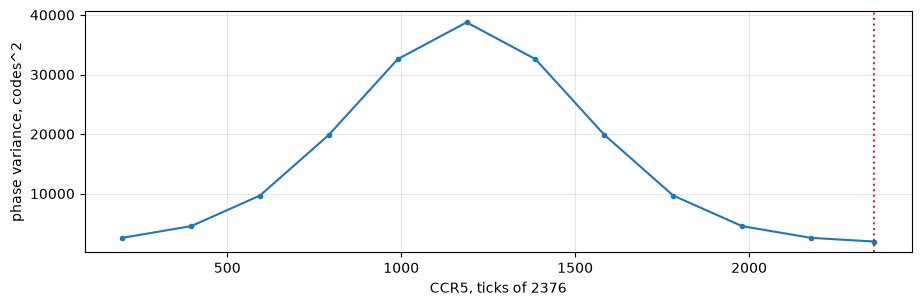

sample point CCR5 2360 of 2376 (was 2360): variance 1956 there, 38765 at tick 1188


In [4]:
from coaxial.draw.figures import figure, show

scan = c.sample_point_scan()
ticks = [row['trigger'] for row in scan['table']]
variance = [row['variance'] for row in scan['table']]
fig, (panel,) = figure()
panel.plot(ticks, variance, '.-')
panel.axvline(scan['best'], linestyle=':', color='C3')
panel.set_xlabel('CCR5, ticks of %d' % scan['period'])
panel.set_ylabel('phase variance, codes^2')
show(fig)
print('sample point CCR5 %d of %d (was %d): variance %.0f there, %.0f at tick %d'
      % (scan['best'], scan['period'], scan['was'], min(variance), max(variance),
         ticks[variance.index(max(variance))]))

Each phase's code at zero current becomes its offset, applied to the record unless it is past `limit_codes`: a phase reading -52 A with nothing connected is a fault in that chain, and zeroing it would hide it. Then the three shunt chains against each other from `ia + ib + ic = 0`, a current vector held on each phase axis in turn and the sums solved for the two gain ratios - the offsets taken as measured, not as the record holds them, so a declined one still sits under the reading.

In [5]:
offsets = c.offsets()
for name, row in offsets.items():
    print('%-8s %+6d codes  %s' % (name, row['offset_raw'],
                                   'SUSPECT - reported, not applied' if row['suspect'] else 'applied'))
mismatch = c.gain_mismatch()
if mismatch['measured']:
    print('relative gains %s, mismatch %.2f %%'
          % ({n[-1]: round(g, 4) for n, g in mismatch['relative_gain'].items()},
             mismatch['mismatch_pct']))
else:
    print('gain mismatch not measured -', mismatch['why'])

Phase U   +1400 codes  applied
Phase V   -8030 codes  SUSPECT - reported, not applied
Phase W    +360 codes  applied


relative gains {'U': 0.9983, 'V': 1.0083, 'W': 0.9934}, mismatch 1.50 %


## 3 The inverter: the sign and the dead time

A small positive d voltage on phase a, and the current it makes says which way the shunts read; `drv_sign` is set from it. Then `vd` against a held d current from 0.25 to 4 A: R is the slope, and what is left is the dead-time curve `v_dt tanh(I / i_knee)` folded across the three phases - a vector on phase a puts I on a and -I/2 on b and c, so the three errors land on d as two thirds of their sum - fitted on a grid and refined once. Mandatory at weak saliency: the voltage error is an angle error in every estimate built on the applied voltage. The fit is unfolded into the record's eight-row table by current step.

In [6]:
sign = c.sign_check()
print('sign %+d, from id %.3f A' % (sign['sign'], sign['id']) if sign['measured']
      else 'sign not measured - ' + sign['why'])
dead = c.deadtime()
if dead['measured']:
    print('R %.4f ohm, V_dt %.3f V, knee %.2f A; fit residual %.4f V rms over %d points'
          % (dead['r'], dead['v_dt'], dead['i_knee'], dead['residual_volts'],
             len(dead['points'])))
    print('table written, %.3f A a row: %s' % (dead['step'], [round(v, 3) for v in dead['table']]))
else:
    print('dead time not measured -', dead['why'])

sign +1, from id 6.000 A


R 0.0514 ohm, V_dt 0.497 V, knee 0.30 A; fit residual 0.0016 V rms over 7 points
table written, 0.571 A a row: [0.0, 0.476, 0.497, 0.497, 0.497, 0.497, 0.497, 0.497]


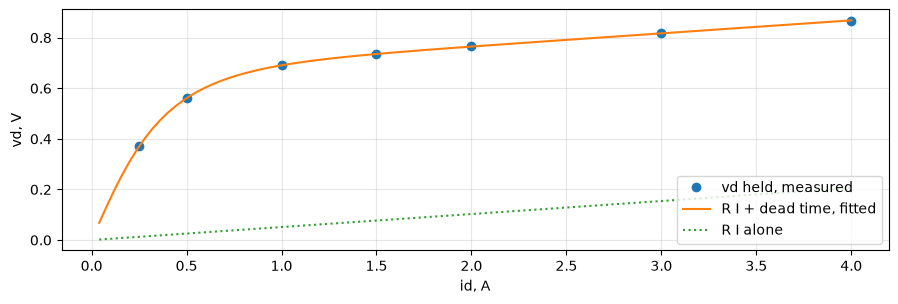

at 4.00 A: 0.867 V held, of which R I is 0.206 V and the dead time 0.663 V


In [7]:
import math

def bend(amps):
    return dead['v_dt'] * math.tanh(amps / dead['i_knee'])

def folded(amps):
    return (2.0 / 3.0) * (bend(amps) + bend(amps / 2.0))

amps = [i for i, _ in dead['points']]
grid = [max(amps) * k / 100.0 for k in range(1, 101)]
fig, (panel,) = figure()
panel.plot(amps, [v for _, v in dead['points']], 'o', label='vd held, measured')
panel.plot(grid, [dead['r'] * i + folded(i) for i in grid], label='R I + dead time, fitted')
panel.plot(grid, [dead['r'] * i for i in grid], ':', label='R I alone')
panel.set_xlabel('id, A')
panel.set_ylabel('vd, V')
panel.legend(loc='lower right')
show(fig)
i_top, v_top = dead['points'][-1]
print('at %.2f A: %.3f V held, of which R I is %.3f V and the dead time %.3f V'
      % (i_top, v_top, dead['r'] * i_top, folded(i_top)))

## 4 The motor: the inductance map and the flux

L against the injection angle at four d biases, from `V T / i_h`: the mean is L, the second harmonic over it is dL/L - the saturation saliency an SPM has and a salient rotor adds to - and the fourth is the secondary harmonic the demodulator has to live with. The d axis is angle zero, so Ld and Lq fall out of the zero-bias row, and the bias rows show Ld bending under current. Then lambda from an I/f spin at 300 rad/s and 2 A: the back-EMF in the command frame is `v - R i - j omega L i`, its magnitude over omega is the flux, and the load angle is where the rotor sat behind the command.

In [8]:
lmap = c.l_map()
if lmap['measured']:
    print('Ld %.1f uH, Lq %.1f uH at zero bias; dL/L %.3f, fourth harmonic %.3f of L'
          % (lmap['ld'] * 1e6, lmap['lq'] * 1e6, lmap['dl_over_l'],
             lmap['rows'][0.0]['h4_over_l']))
    for bias, row in lmap['rows'].items():
        if row.get('measured'):
            print('  %.0f A of d bias: L %.2f uH mean, Ld %.2f, Lq %.2f, dL/L %.3f'
                  % (bias, row['mean'] * 1e6, row['ld'] * 1e6, row['lq'] * 1e6, row['dl_over_l']))
else:
    print('L map not measured - the injection saw no current')
flux = c.flux()
print('lambda %.5f V.s from a spin at %.0f rad/s; load angle %.2f rad, back-EMF (%.3f, %.3f) V'
      % (flux['lambda'], flux['omega'], flux['load_angle'], flux['e'][0], flux['e'][1])
      if flux['measured'] else 'flux not measured - no current under I/f')

Ld 19.5 uH, Lq 29.4 uH at zero bias; dL/L 0.202, fourth harmonic 0.020 of L
  0 A of d bias: L 24.49 uH mean, Ld 19.55, Lq 29.44, dL/L 0.202
  1 A of d bias: L 23.58 uH mean, Ld 17.93, Lq 29.23, dL/L 0.240
  2 A of d bias: L 22.73 uH mean, Ld 16.47, Lq 29.00, dL/L 0.276
  3 A of d bias: L 22.04 uH mean, Ld 15.29, Lq 28.78, dL/L 0.306


lambda 0.00546 V.s from a spin at 300 rad/s; load angle -0.42 rad, back-EMF (0.663, 1.499) V


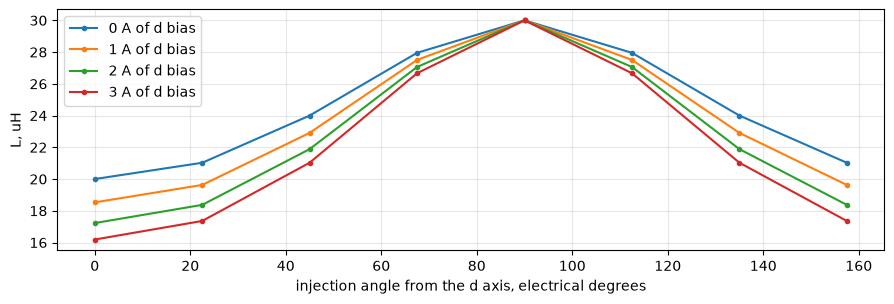

In [9]:
angles = [math.degrees(a) for a in lmap['angles']]
fig, (panel,) = figure()
for bias, row in lmap['rows'].items():
    if row.get('measured'):
        panel.plot(angles, [x * 1e6 for x in row['l']], '.-', label='%.0f A of d bias' % bias)
panel.set_xlabel('injection angle from the d axis, electrical degrees')
panel.set_ylabel('L, uH')
panel.legend(loc='upper left')
show(fig)

The four constants into a `Parameters`: R from the dead-time sweep, Ld and Lq from the map, lambda from the flux step, pole pairs from the record - no terminal measurement recovers those. A step that saw no current reports `measured: False` and the record's value stands in. `measured` and `source` travel with the set, so constants recovered from a machine and constants estimated from a label cannot be confused later. The stand-in's machine is `BENCH_MOTOR`, invented to be recoverable, so on it the identification can be read against a truth; a board has an instrument, or nothing.

In [10]:
from coaxial.model.motor import BENCH_MOTOR, Parameters

p = device.drive.params()

def got(step, key, fallback):
    block = c.results.get(step) or {}
    return block[key] if block.get('measured') is not False and key in block else fallback

identified = Parameters(
    name='commissioned',
    r=got('deadtime', 'r', p['motor_r_uohm']),
    ld=got('l_map', 'ld', p['motor_ld_nh']),
    lq=got('l_map', 'lq', p['motor_lq_nh']),
    lam=got('flux', 'lambda', p['motor_lambda_uvs']),
    poles=int(p['motor_pole_pairs']),
    sat=0.3, i_sat=4.0,      # the bend's shape as the record has it; the map shows it, no step fits it
    measured=True, source='commissioning on this rig')
print(identified)
vdc = device.drive.state()['vdc']
print('link %.2f V; saliency Lq/Ld %.3f' % (vdc, identified.saliency))
truth = BENCH_MOTOR if SIMULATED else None
if truth:
    for name in ('r', 'ld', 'lq', 'lam'):
        print('   %-3s identified %.6g against the stand-in\'s %.6g: %+.1f %%'
              % (name, getattr(identified, name), getattr(truth, name),
                 100.0 * (getattr(identified, name) / getattr(truth, name) - 1.0)))

<commissioned measured: R 0.0514 ohm, Ld 19.5 uH, Lq 29.4 uH, lambda 0.00546 Wb, 7 pole pairs, KV 144>
link 24.77 V; saliency Lq/Ld 1.506
   r   identified 0.0514154 against the stand-in's 0.05: +2.8 %
   ld  identified 1.95459e-05 against the stand-in's 2e-05: -2.3 %
   lq  identified 2.94439e-05 against the stand-in's 3e-05: -1.9 %
   lam identified 0.00546238 against the stand-in's 0.005: +9.2 %


## 5 The budget, the gains and the decision

Three steps are arithmetic on what was measured, in `coaxial.model.sensorless`. The budget picks the injection frequency and amplitude for the best SNR under the constraints - the current loop's bandwidth from R, L and the sampling rate, the injection current under `i_h_max`, the estimator bandwidth wanted. The gains are the loop PI from that bandwidth, the Kalman-form PLL gains from the measured noise, and the crossover: the speed where `omega lambda` clearly exceeds the voltage floor the dead-time residual and the uncertainty in `R i` leave, which sets the blend band. All of it is written to the record and the drive reloads. The decision is injection when the budget clears the threshold, else an I/f start.

In [11]:
budget = c.budget()
choice, loop = budget['choice'], budget['loop']
print('AFE %s: sigma_i %.4f A' % (budget['afe'], budget['known']['sigma_i']))
print('current loop %.0f Hz, limited by %s: kp %.4f V/A, ki %.1f V/(A s)'
      % (loop['bw_hz'], loop['limited_by'], loop['kp'], loop['ki']))
if choice:
    print('injection %.0f Hz over %d period(s), %.3f V, %.3f A peak, SNR %.1f dB, limited by %s'
          % (choice['f_inj_hz'], choice['periods'], choice['v_inj'], choice['i_h_peak'],
             choice['snr_db'], choice['limited_by']))
else:
    print('no injection clears the constraints')
gains = c.gains()
closed = dict(gains['written'])
kal, cross = gains['kalman'], gains['crossover']
if kal:
    print('PLL %.0f Hz, zeta %.2f: l1 %.4f, l2 %.2f; sigma_theta estimate %.3f rad'
          % (kal['wn_hz'], kal['zeta'], kal['l1'], kal['l2'], kal['sigma_theta_est']))
print('crossover: %.3f V of floor, %.1f rad/s electrical = %.0f rpm; blend %.0f to %.0f rad/s'
      % (cross['floor_volts'], cross['omega_e'], cross['rpm'],
         closed['drv_w_lo_mrad_s'], closed['drv_w_hi_mrad_s']))
decision = c.decide()
print('decision: %s (SNR %.1f dB against %.0f)'
      % (decision['method'], decision['snr_db'], decision['threshold_db']))

AFE noisy: sigma_i 0.1616 A
current loop 2500 Hz, limited by sampling: kp 0.3070 V/A, ki 807.6 V/(A s)
injection 25000 Hz over 1 period(s), 0.297 V, 0.152 A peak, SNR 20.0 dB, limited by target
PLL 71 Hz, zeta 0.70: l1 0.0250, l2 7.90; sigma_theta estimate 0.250 rad
crossover: 0.125 V of floor, 68.9 rad/s electrical = 94 rpm; blend 69 to 138 rad/s
decision: injection (SNR 20.0 dB against 10)


## 6 A first run, under the closed-form tune

`verify` runs the drive sensorless under whatever the record holds and judges the innovation: white by Ljung-Box over seven lags, and its deviation as the `sigma_theta` proxy. Under injection it locks first, then fires the polarity pulses - two along `theta_hat`, and the one that saturates peaks higher; the estimate is flipped by pi when the opposed one did - then takes half a second of window at 0.5 A of q current. The report line is the executive's one sentence: zero-speed or not, the SNR, the closed-loop floor as a share of the rated speed, the loop bandwidth, the proxy.

In [12]:
first = c.verify(iq=0.5, seconds=1.0)
pol = c.results.get('polarity')
if pol:
    print('polarity pulses: aligned %.0f, opposed %.0f, %s'
          % (pol['pol_pos'], pol['pol_neg'], 'theta_hat flipped by pi' if pol['flipped'] else 'theta_hat kept'))
lb = first['ljung_box']
print('%s: sigma_theta %.2f deg, iq %.2f A, omega_hat %.1f rad/s, fault %s'
      % (first['method'], first['sigma_theta_deg'], first['iq'], first['omega_hat'], first['fault']))
print('innovation Ljung-Box Q %.2f against %.2f at %d lags: %s'
      % (lb['q'], lb['threshold'], lb['lags'], 'white' if lb['white'] else 'NOT white'))
print(c.report()['line'])

polarity pulses: aligned 34, opposed 18, theta_hat kept
injection: sigma_theta 11.21 deg, iq 0.50 A, omega_hat 0.0 rad/s, fault None
innovation Ljung-Box Q 2.02 against 14.07 at 7 lags: white
zero-speed: yes (SNR 20 dB), min closed-loop 3 %, iloop 2500 Hz, sigma_theta 11.2 deg at 0 %


## 7 A tune searched against this machine

`gains` wrote a tune in closed form. This searches for one instead: `run_job` takes the motor and the board's limits, so every candidate is scored against the firmware's own C driving plants drawn around **this** machine - R up to a hot winding, L a quarter either way, the dead time either side of the commissioned one, the rotor anywhere. A run locks, rises to half the link's no-load speed, holds and descends. Cost is `sigma_theta + speed_err + 10 x trip`; `robust` is its mean plus its 90th percentile, so a tune that occasionally loses the rotor scores worse than one that is merely average. Six candidates and three draws here, against the tool's 48 and 16 over five link voltages.

In [13]:
import os
import sys

sys.path.insert(0, os.path.join('..', 'host'))   # the Monte Carlo is a tool beside the library, not part of it
from tools.sim import montecarlo as mc

In [14]:
import time

fields = {k: getattr(identified, k) for k in ('name', 'r', 'ld', 'lq', 'lam', 'poles',
                                             'j', 'b', 'sat', 'i_sat', 'measured', 'source')}
i_max, i_trip = p['drv_i_max_ma'], p['drv_i_trip_ma']
knobs = mc.candidates(6, seed=3)
jobs = [{'vdc': vdc, 'knobs': k, 'seed': 1000 * i + s, 'motor': fields,
         'i_max': i_max, 'i_trip': i_trip, 'i_h_max': 1.0, 'k_prop': 0.0}
        for i, k in enumerate(knobs) for s in range(3)]
t0 = time.perf_counter()
with mc.pool() as pool:
    runs = mc.sweep(pool, jobs, progress=False)
took = time.perf_counter() - t0
score = mc.score(runs).sort_values('robust')
best = score.iloc[0]
print(score.to_string(index=False, columns=['robust', 'mean', 'p90'] + list(mc.KNOBS),
                      float_format='%.4f'))
runs['candidate'] = runs.seed // 1000
by = runs.groupby('candidate').agg(cost=('cost', 'mean'), trips=('trip', 'sum'),
                                   i_peak=('i_peak', 'max'), i_h=('i_h', 'max'))
print(by.round(3).to_string())
print('%d runs in %.1f s, %d tripped the stage at i_trip %.0f A; '
      'best robust %.3f = mean %.3f + p90 %.3f, i_max %.0f A'
      % (len(runs), took, int(runs.trip.sum()), i_trip, best['robust'], best['mean'],
         best['p90'], i_max))

 robust    mean     p90      bw_i    f_pll   zeta  v_inj  n_inj     w_lo  w_ratio    bw_w
 0.6579  0.2594  0.3985 1538.2594  71.1231 1.0870 0.1301      4 171.8142   3.1210  7.8188
 2.5824  1.0718  1.5106  326.3185  47.1383 0.8218 0.0399      2 472.5363   2.4998  1.5650
 4.3618  1.7696  2.5923 1796.9124  22.0094 0.6241 0.0511      1 215.6562   2.0760  1.6642
 4.9502  2.4033  2.5469  693.1668 117.6864 1.0018 0.1415      2  74.2742   2.1729  3.3597
27.3641 13.2225 14.1416  517.7425 179.6790 0.5783 0.0233      2 125.4686   3.7706 16.4201
28.2832 14.1416 14.1416 1072.0477 373.1851 0.9190 0.0906      4 787.0318   1.6635  5.5023
             cost  trips   i_peak    i_h
candidate                               
0          13.222      3  102.833  0.341
1           1.770      0    2.647  0.374
2           0.259      0    4.319  1.000
3           2.403      0   90.365  1.000
4          14.142      3  106.122  1.000
5           1.072      0   14.895  0.584
18 runs in 2.3 s, 6 tripped the stage at i

## 8 The record written, and the drive verified under it

`design` turns the winning knobs into the firmware's parameters - kp and ki from the loop bandwidth, l1 and l2 from the PLL's, the injection volts and the demodulator gain, the blend band. `configure` writes them into the record in SI and reloads, and answers what the record holds after the wire's rounding; the closed-form value stands beside each for comparison. Then `verify` again, under the searched tune.

In [15]:
tune = mc.design({k: float(best[k]) for k in mc.KNOBS}, vdc, identified, i_max, i_trip, 1.0)
written = device.drive.configure(
    motor_r_uohm=identified.r, motor_ld_nh=identified.ld, motor_lq_nh=identified.lq,
    motor_lambda_uvs=identified.lam,
    drv_kp_mv_per_a=tune['kp'], drv_ki_v_per_as=tune['ki'],
    drv_l1_milli=tune['l1'], drv_l2_milli=tune['l2'],
    drv_inj_mv=tune['inj_volts'], drv_inj_periods=tune['inj_periods'],
    drv_eps_gain_ua_per_rad=tune['eps_gain'],
    drv_w_lo_mrad_s=tune['w_lo'], drv_w_hi_mrad_s=tune['w_hi'])['params']
print('%-24s %-12s %s' % ('written for %.1f V' % vdc, 'searched', 'closed form'))
for name, value in written.items():
    print('%-24s %-12.6g %s' % (name, value, '%.6g' % closed[name] if name in closed else '-'))
check = c.verify(iq=0.5, seconds=1.0)
lb = check['ljung_box']
print('%s under the searched tune: sigma_theta %.2f deg (was %.2f), Q %.2f against %.2f, %s, fault %s'
      % (check['method'], check['sigma_theta_deg'], first['sigma_theta_deg'], lb['q'],
         lb['threshold'], 'white' if lb['white'] else 'NOT white', check['fault']))

written for 24.8 V       searched     closed form
motor_r_uohm             0.0514154    -
motor_ld_nh              1.95459e-05  -
motor_lq_nh              2.94439e-05  -
motor_lambda_uvs         0.00546238   -
drv_kp_mv_per_a          0.188915     0.307027
drv_ki_v_per_as          496.938      807.631
drv_l1_milli             0.155436     0.0249809
drv_l2_milli             31.9522      7.89944
drv_inj_mv               0.488648     0.29717
drv_inj_periods          4            1
drv_eps_gain_ua_per_rad  0.168082     0.102218
drv_w_lo_mrad_s          171.814      68.8797
drv_w_hi_mrad_s          536.227      137.759


injection under the searched tune: sigma_theta 1.70 deg (was 11.21), Q 2.25 against 14.07, white, fault None


`device.calibration.save()` is what keeps the record across a reset - the drive reloads its parameters from it at boot, so a board runs the same tune after a power cycle that it ran before. The drive reads them back through the record, the one place any of them lives. The stage this section armed goes down here, and the converters go back to the meter, before the device is closed.

In [16]:
print('saved:', device.calibration.save())
after = device.drive.params()
for name in sorted(after):
    print('   %-26s %-14.6g %s' % (name, after[name], 'written today' if name in written else ''))
print('%d parameters in the record, %d of them written today' % (len(after), len(written)))
device.drive.off()
device.gates.off()
device.gates.control.configure(sync=False)
print('stage armed:', device.gates.is_on())

saved: True
   drv_dt_step_ma             0.571429       
   drv_eps_gain_ua_per_rad    0.168082       written today
   drv_i_max_ma               5              
   drv_i_trip_ma              100            
   drv_inj_mv                 0.488648       written today
   drv_inj_periods            4              written today
   drv_inj_phase_mrad         0              
   drv_ki_v_per_as            496.938        written today
   drv_kp_mv_per_a            0.188915       written today
   drv_l1_milli               0.155436       written today
   drv_l2_milli               31.9522        written today
   drv_sigma_i_ua             0.161622       
   drv_sign                   1              
   drv_trigger_ticks          2360           
   drv_v_frac_ppm             0.95           
   drv_w_hi_mrad_s            536.227        written today
   drv_w_lo_mrad_s            171.814        written today
   motor_lambda_uvs           0.00546238     written today
   motor_ld_nh                

In [17]:
device.close()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 9 Conclusions

In [18]:
def line(number, name, block, text):
    if isinstance(block, dict) and block.get('measured') is False:
        print('%2d. %-13s not measured - %s' % (number, name, block.get('why', 'no current')))
    else:
        print('%2d. %-13s %s' % (number, name, text()))

line(1, 'AFE', afe, lambda: 'sigma_i %.4f A, ENOB %.1f, pickup %.4f A; ISR %.1f us of a %.0f us period'
     % (afe['sigma_i'], afe['enob'], max(afe['pickup_amps'].values()), lat['isr_cost_us'], 1e6 / c.fs))
line(2, 'sample point', scan, lambda: 'CCR5 %d of %d (was %d); variance %.0f there, %.0f mid-period'
     % (scan['best'], scan['period'], scan['was'], min(variance), max(variance)))
line(3, 'offsets', offsets, lambda: ' '.join(
    '%s %+d%s' % (n[-1], v['offset_raw'], ' SUSPECT' if v['suspect'] else '')
    for n, v in offsets.items()))
line(4, 'chains', mismatch, lambda: 'relative gains %s, mismatch %.2f %%'
     % (' '.join('%.4f' % g for g in mismatch['relative_gain'].values()), mismatch['mismatch_pct']))
line(5, 'sign', sign, lambda: '%+d, id %.3f A' % (sign['sign'], sign['id']))
line(6, 'dead time', dead, lambda: 'R %.4f ohm, V_dt %.3f V, knee %.2f A, residual %.4f V'
     % (dead['r'], dead['v_dt'], dead['i_knee'], dead['residual_volts']))
line(7, 'L map', lmap, lambda: 'Ld %.1f uH, Lq %.1f uH, dL/L %.3f; Ld %.1f uH at 3 A of bias'
     % (lmap['ld'] * 1e6, lmap['lq'] * 1e6, lmap['dl_over_l'], lmap['rows'][3.0]['ld'] * 1e6))
line(8, 'flux', flux, lambda: 'lambda %.5f V.s = KV %.0f, load angle %.2f rad'
     % (flux['lambda'], identified.kv, flux['load_angle']))
line(9, 'budget', budget, lambda: 'f_inj %.0f Hz, V %.2f, i_h %.3f A, SNR %.1f dB, limited by %s'
     % (choice['f_inj_hz'], choice['v_inj'], choice['i_h_peak'], choice['snr_db'], choice['limited_by']))
line(10, 'gains', gains, lambda: 'iloop %.0f Hz, PLL %.0f Hz, crossover %.0f rpm = %.1f %% of rated'
     % (loop['bw_hz'], (kal or {}).get('wn_hz', 0.0), cross['rpm'], 100.0 * cross['rpm'] / c.rated_rpm))
line(11, 'decision', decision, lambda: '%s (SNR %.1f dB against %.0f)'
     % (decision['method'], decision['snr_db'], decision['threshold_db']))
line(12, 'first run', first, lambda: 'sigma_theta %.2f deg, innovation %s, fault %s'
     % (first['sigma_theta_deg'], 'white' if first['ljung_box']['white'] else 'NOT white', first['fault']))
print('13. search        %d runs, %d tripped; best robust %.3f (mean %.3f, p90 %.3f): '
      'bw_i %.0f Hz, PLL %.0f Hz, zeta %.2f, v_inj %.3f x %d, w_lo %.0f, ratio %.2f, bw_w %.1f Hz'
      % (len(runs), int(runs.trip.sum()), best['robust'], best['mean'], best['p90'],
         best['bw_i'], best['f_pll'], best['zeta'], best['v_inj'], int(best['n_inj']),
         best['w_lo'], best['w_ratio'], best['bw_w']))
print('14. tune          closed form -> searched: kp %.3f -> %.3f V/A, ki %.0f -> %.0f, '
      'l1 %.4f -> %.4f, l2 %.2f -> %.2f'
      % (closed['drv_kp_mv_per_a'], written['drv_kp_mv_per_a'], closed['drv_ki_v_per_as'],
         written['drv_ki_v_per_as'], closed['drv_l1_milli'], written['drv_l1_milli'],
         closed['drv_l2_milli'], written['drv_l2_milli']))
print('                  injection %.3f V x %d -> %.3f V x %d, eps gain %.3f -> %.3f, '
      'blend %.0f-%.0f -> %.0f-%.0f rad/s'
      % (closed['drv_inj_mv'], closed['drv_inj_periods'], written['drv_inj_mv'],
         written['drv_inj_periods'], closed['drv_eps_gain_ua_per_rad'],
         written['drv_eps_gain_ua_per_rad'], closed['drv_w_lo_mrad_s'], closed['drv_w_hi_mrad_s'],
         written['drv_w_lo_mrad_s'], written['drv_w_hi_mrad_s']))
print('15. verified      sigma_theta %.2f -> %.2f deg, innovation %s, fault %s; '
      'saved, %d parameters read back, %d written today'
      % (first['sigma_theta_deg'], check['sigma_theta_deg'],
         'white' if check['ljung_box']['white'] else 'NOT white', check['fault'],
         len(after), len(written)))
if truth:
    print('16. truth         R %+.1f %%, Ld %+.1f %%, Lq %+.1f %%, lambda %+.1f %% off the stand-in\'s'
          % tuple(100.0 * (getattr(identified, k) / getattr(truth, k) - 1.0)
                  for k in ('r', 'ld', 'lq', 'lam')))

 1. AFE           sigma_i 0.1616 A, ENOB 9.5, pickup 0.0000 A; ISR 3.4 us of a 20 us period
 2. sample point  CCR5 2360 of 2376 (was 2360); variance 1956 there, 38765 mid-period
 3. offsets       U +1400 V -8030 SUSPECT W +360
 4. chains        relative gains 0.9983 1.0083 0.9934, mismatch 1.50 %
 5. sign          +1, id 6.000 A
 6. dead time     R 0.0514 ohm, V_dt 0.497 V, knee 0.30 A, residual 0.0016 V
 7. L map         Ld 19.5 uH, Lq 29.4 uH, dL/L 0.202; Ld 15.3 uH at 3 A of bias
 8. flux          lambda 0.00546 V.s = KV 144, load angle -0.42 rad
 9. budget        f_inj 25000 Hz, V 0.30, i_h 0.152 A, SNR 20.0 dB, limited by target
10. gains         iloop 2500 Hz, PLL 71 Hz, crossover 94 rpm = 3.1 % of rated
11. decision      injection (SNR 20.0 dB against 10)
12. first run     sigma_theta 11.21 deg, innovation white, fault None
13. search        18 runs, 6 tripped; best robust 0.658 (mean 0.259, p90 0.399): bw_i 1538 Hz, PLL 71 Hz, zeta 1.09, v_inj 0.130 x 4, w_lo 172, ratio 3.12, b

Three steps decide rather than measure. **The sample point** needs the stage switching: with nothing on the gates the scan is a walk through noise, which once picked 990 of 2376 - mid-period, where the pickup is worst. On the stand-in the variance mid-period is twenty times the floor at 2360, and the pickup on the zero vector reads zero because the sample point already sits past the ringing. **An offset past `limit_codes`** is reported, not applied: a phase reading -52 A with nothing connected is a fault in that chain, and storing it as the zero hides it - which is why Phase V stays SUSPECT in finding 3, and why the gain solve takes the offsets as measured rather than as the record holds them. **The method** needs saliency - the demodulator's gain goes as `Lq - Ld` - so a machine with little of it lands on I/f. The polarity comes from a saturation pulse either way: injection locks the d **axis**, and only saturation says which end is the magnet.

The search scores the firmware's own C, not a model of it: `run_job` takes the motor and the board's limits, so every candidate drives plants drawn around **this** machine - R up to a hot winding, L a quarter either way, the dead time either side of the commissioned one, the rotor anywhere. Cost is `sigma_theta + speed_err + 10 x trip`, and `robust` is its mean plus its 90th percentile, so a tune that occasionally loses the rotor scores worse than one that is merely average: eight of the eighteen runs tripped the stage at 100 A, and the winner tripped none at under 5 A of peak. Six candidates and three draws here, against the tool's 48 and 16 over five link voltages. `design` turns the winning knobs into the firmware's parameters - kp and ki from the loop bandwidth, l1 and l2 from the PLL's, the injection volts and the demodulator gain, the blend band - and `configure` writes them in SI and reloads. On the stand-in the innovation's spread is its noise over the demodulator gain and the periods averaged, so the fall from 11.2 to 1.7 degrees is the arithmetic of a louder, longer injection; on a board it is the machine's.

The stand-in was built to be recoverable: `BENCH_MOTOR` is 0.05 ohm, 20 and 30 uH and 0.005 V.s, its dead time 0.5 V with a 0.3 A knee, its chains 1.0, 1.01 and 0.995. R, Ld, Lq, the dead time and the gain mismatch come back within 3 %; lambda lands 9 % high, and the crossover, three floors over lambda, inherits it. `calibration.save()` is what keeps the record across a reset - the drive reloads its parameters from it at boot, so a board runs the same tune after a power cycle that it ran before. The record now holds what the drive runs on after the next reset, the one place any of it lives (invariant 7); every number is the board's and every verdict this executive's (invariant 10), which is why the steps live in the host and not in the firmware. Nothing here has closed a current loop through a winding: every step has run dry on the bench board and none against a motor (TODO), and the record's ids 15 to 44 are placeholders until one is.

**At the bench.** Flip `SIMULATED` and name the port, with a motor on the phases and the gate drivers' supply released by the STO chain - `gate_supply()` says whether it is, and under 7.3 V every switching step reads a dry stage as `measured: False`. `tools/bench/commission.py --arm --port COM4` is the same twelve steps as one command under one `finally`. Compare finding 2 against the scan's figure: a best tick mid-period means the stage was not switching. Compare finding 6 against a DMM across a phase pair - half the line-to-line resistance is R - and finding 8 against the nameplate KV, whose flux the stand-in's 144 does not pretend to match. Read finding 3 before anything else: a SUSPECT chain is a fault to find, not an offset to store. The stand-in could not show switch pickup, a dead time that is not a clean tanh, an innovation that is not white, or a stage that trips - the search's trips are the model's, and the board's `i_trip` sits at the rating (invariant 10). Run the search from `tools/sim/montecarlo.py` at the link voltage the machine will see before believing a tune found at 24.8 V.

## References

* `host/coaxial/control/commission.py` - the twelve steps, and the one-line report
* `host/coaxial/model/sensorless.py` - the arithmetic: the budget, the loop and PLL gains, the crossover, Ljung-Box
* `host/tools/sim/montecarlo.py` - the search: the plants drawn around the machine, the cost, `design`
* `host/tools/bench/commission.py` - the procedure as one command at the bench
* `host/coaxial/model/motor.py` - `Parameters`, and `BENCH_MOTOR` - the stand-in's truth
* `host/coaxial/simulated/drive/` - the stand-in this ran on: the machine, the pickup, the polarity readings
* `host/tests/test_sensorless.py` - the arithmetic and the commissioning pinned against the stand-in
* `host/tests/test_drive_core.py` - the firmware's law through the host gcc, which the search drives